STEP 0: Install libraries

In [3]:
pip install pandas numpy scikit-learn imbalanced-learn xgboost shap matplotlib


STEP 1: Import libraries

In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

import shap
import matplotlib.pyplot as plt


STEP 2: Load dataset

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd

# Assuming '100 diabetes.csv' is in the root of your Google Drive
df = pd.read_csv('/content/drive/My Drive/100 diabetes.csv')

print('DataFrame loaded successfully! Here are the first 5 rows:')
display(df.head())

DataFrame loaded successfully! Here are the first 5 rows:


,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [7]:
print("Dataset Shape:", df.shape)

Dataset Shape: (100000, 31)


In [8]:
print(df.columns)



Index(['age', 'gender', 'ethnicity', 'education_level', 'income_level',
       'employment_status', 'smoking_status', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp',
       'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol',
       'ldl_cholesterol', 'triglycerides', 'glucose_fasting',
       'glucose_postprandial', 'insulin_level', 'hba1c', 'diabetes_risk_score',
       'diabetes_stage', 'diagnosed_diabetes'],
      dtype='object')


In [9]:
target = "diagnosed_diabetes"


STEP 3: Define target & remove leakage columns

In [10]:
leakage_cols = ["diabetes_risk_score", "diabetes_stage"]

X = df.drop(columns=[target] + leakage_cols)
y = df[target]

STEP 4: ENCODE CATEGORICAL COLUMNS

In [11]:
# Find categorical columns
categorical_cols = X.select_dtypes(include=["object"]).columns
print("Categorical columns:", categorical_cols)

# One-hot encode
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("Shape after encoding:", X_encoded.shape)


Categorical columns: Index(['gender', 'ethnicity', 'education_level', 'income_level',
       'employment_status', 'smoking_status'],
      dtype='object')
Shape after encoding: (100000, 40)


STEP 5: Train–Test Split (after encoding)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


STEP 6: Feature Scaling

In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


STEP 7: Handle Class Imbalance (SMOTE)

In [14]:
smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(
    X_train_scaled, y_train
)

print("Class distribution after SMOTE:")
print(np.bincount(y_train_bal))


Class distribution after SMOTE:
[47998 47998]


CENTRALIZED MODEL (MAIN ACCURACY)
🔹 STEP 8: Train XGBoost model

In [15]:
central_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

central_model.fit(X_train_bal, y_train_bal)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

STEP 9: Evaluate Centralized Model

In [16]:
y_pred = central_model.predict(X_test_scaled)
y_prob = central_model.predict_proba(X_test_scaled)[:, 1]

print("Centralized Accuracy:", accuracy_score(y_test, y_pred))
print("Centralized ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))


Centralized Accuracy: 0.91975
Centralized ROC-AUC: 0.9435402916666666
              precision    recall  f1-score   support

           0       0.83      1.00      0.91      8000
           1       1.00      0.87      0.93     12000

    accuracy                           0.92     20000
   macro avg       0.92      0.93      0.92     20000
weighted avg       0.93      0.92      0.92     20000



In [17]:
X_train_df = pd.DataFrame(X_train_bal, columns=X_encoded.columns)
y_train_df = pd.Series(y_train_bal)

clients_X = np.array_split(X_train_df, 3)
clients_y = np.array_split(y_train_df, 3)


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


STEP 11: Train local models

In [18]:
local_models = []

for i in range(3):
    model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
    model.fit(clients_X[i], clients_y[i])
    local_models.append(model)


STEP 12: Federated aggregation

In [19]:
local_probs = []

for model in local_models:
    probs = model.predict_proba(X_test_scaled)[:, 1]
    local_probs.append(probs)

global_prob = np.mean(local_probs, axis=0)
global_pred = (global_prob > 0.5).astype(int)


STEP 13: Evaluate federated model

In [20]:
print("Federated Accuracy:", accuracy_score(y_test, global_pred))
print("Federated ROC-AUC:", roc_auc_score(y_test, global_prob))
print(classification_report(y_test, global_pred))


Federated Accuracy: 0.9199
Federated ROC-AUC: 0.9428642395833333
              precision    recall  f1-score   support

           0       0.83      1.00      0.91      8000
           1       1.00      0.87      0.93     12000

    accuracy                           0.92     20000
   macro avg       0.92      0.93      0.92     20000
weighted avg       0.93      0.92      0.92     20000



STEP 14: SHAP summary plot

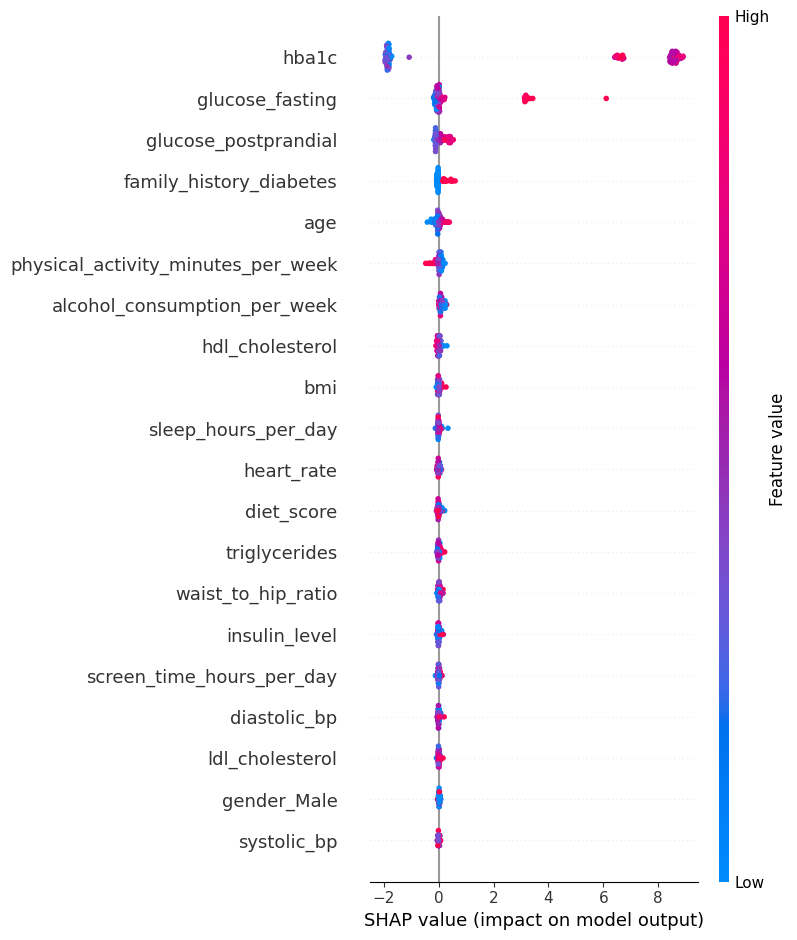

In [21]:
explainer = shap.Explainer(central_model)

shap_values = explainer(X_test_scaled[:100])

shap.summary_plot(
    shap_values,
    X_test_scaled[:100],
    feature_names=X_encoded.columns
)


DEMOGRAPHIC ROBUSTNESS CHECK
🔹 STEP 15: Group-wise accuracy example

In [22]:
X_test_df = pd.DataFrame(X_test_scaled, columns=X_encoded.columns)

age_group_idx = X_test_df[X_test_df["age"] > 50].index

print(
    "Accuracy for Age > 50:",
    accuracy_score(y_test.loc[age_group_idx], global_pred[age_group_idx])
)


Accuracy for Age > 50: nan


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:557: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


confusion matrix

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [24]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[ 7996     4]
 [ 1601 10399]]


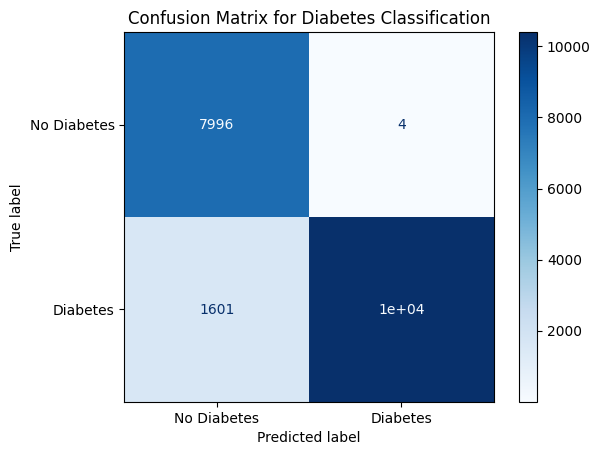

In [25]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Diabetes"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix for Diabetes Classification")
plt.show()


ROC CURVE


In [26]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt


In [27]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc_score)


ROC-AUC Score: 0.9435402916666666


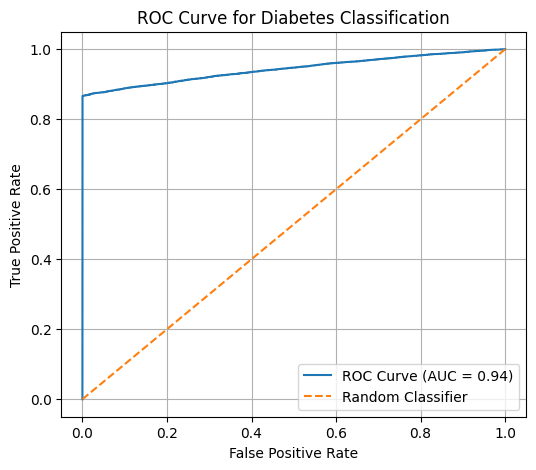

In [28]:
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Diabetes Classification")
plt.legend()
plt.grid(True)
plt.show()


TRAINING vs TESTING GRAPH

In [29]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np


STEP 2: Generate learning curve data

In [30]:
train_sizes, train_scores, test_scores = learning_curve(
    estimator=central_model,
    X=X_train_scaled,
    y=y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)


STEP 3: Compute mean accuracy

In [31]:
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)


STEP 4: Plot Training vs Testing Accuracy

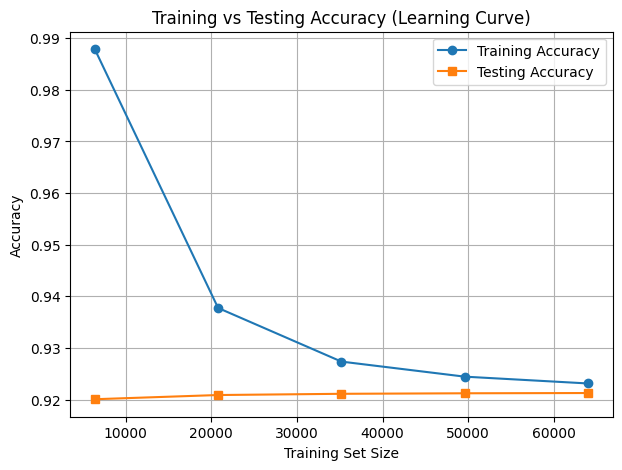

In [32]:
plt.figure(figsize=(7, 5))

plt.plot(train_sizes, train_mean, marker="o", label="Training Accuracy")
plt.plot(train_sizes, test_mean, marker="s", label="Testing Accuracy")

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Training vs Testing Accuracy (Learning Curve)")
plt.legend()
plt.grid(True)
plt.show()


TABLE 1: Dataset Overview

In [33]:
table1 = pd.DataFrame({
    "Attribute": [
        "Dataset Name",
        "Source",
        "Total Records",
        "Total Features",
        "Target Variable"
    ],
    "Value": [
        "Comprehensive Diabetes Dataset",
        "Public Healthcare Dataset",
        df.shape[0],
        df.shape[1],
        "diagnosed_diabetes"
    ]
})

table1


,Attribute,Value
0,Dataset Name,Comprehensive Diabetes Dataset
1,Source,Public Healthcare Dataset
2,Total Records,100000
3,Total Features,31
4,Target Variable,diagnosed_diabetes


TABLE 2: Description of Dataset Features

In [34]:
feature_info = []

for col in df.columns:
    if col == "diagnosed_diabetes":
        continue

    if col in [
        "bmi", "systolic_bp", "diastolic_bp", "glucose_fasting",
        "glucose_postprandial", "hba1c", "cholesterol_total",
        "hdl_cholesterol", "ldl_cholesterol", "triglycerides"
    ]:
        feature_type = "Clinical"
    elif col in [
        "smoking_status", "alcohol_consumption_per_week",
        "physical_activity_minutes_per_week", "diet_score",
        "sleep_hours_per_day", "screen_time_hours_per_day"
    ]:
        feature_type = "Lifestyle"
    else:
        feature_type = "Demographic"

    feature_info.append([
        col,
        feature_type,
        df[col].dtype,
        "Input feature for diabetes prediction"
    ])

table2 = pd.DataFrame(
    feature_info,
    columns=["Feature Name", "Feature Type", "Data Type", "Description"]
)

table2


,Feature Name,Feature Type,Data Type,Description
0,age,Demographic,int64,Input feature for diabetes prediction
1,gender,Demographic,object,Input feature for diabetes prediction
2,ethnicity,Demographic,object,Input feature for diabetes prediction
3,education_level,Demographic,object,Input feature for diabetes prediction
4,income_level,Demographic,object,Input feature for diabetes prediction
5,employment_status,Demographic,object,Input feature for diabetes prediction
6,smoking_status,Lifestyle,object,Input feature for diabetes prediction
7,alcohol_consumption_per_week,Lifestyle,int64,Input feature for diabetes prediction
8,physical_activity_minutes_per_week,Lifestyle,int64,Input feature for diabetes prediction
9,diet_score,Lifestyle,float64,Input feature for diabetes prediction


TABLE 3: Class Distribution of Target Variable

Before balancing

In [35]:
before_balance = df["diagnosed_diabetes"].value_counts().reset_index()
before_balance.columns = ["Class", "Count"]
before_balance["Percentage"] = (
    before_balance["Count"] / before_balance["Count"].sum() * 100
)

before_balance


,Class,Count,Percentage
0,1,59998,59.998
1,0,40002,40.002


After balancing (SMOTE)

In [36]:
from imblearn.over_sampling import SMOTE

X_temp = df.drop(columns=["diagnosed_diabetes", "diabetes_risk_score", "diabetes_stage"])
X_temp = X_temp.select_dtypes(exclude=["object"])
y_temp = df["diagnosed_diabetes"]

X_bal, y_bal = SMOTE(random_state=42).fit_resample(X_temp, y_temp)

after_balance = pd.Series(y_bal).value_counts().reset_index()
after_balance.columns = ["Class", "Count"]
after_balance["Percentage"] = (
    after_balance["Count"] / after_balance["Count"].sum() * 100
)

after_balance


,Class,Count,Percentage
0,1,59998,50.0
1,0,59998,50.0


TABLE 4: Summary Statistics of Key Numerical Features

In [37]:
key_features = [
    "age", "bmi", "glucose_fasting", "glucose_postprandial",
    "hba1c", "systolic_bp", "diastolic_bp"
]

table4 = df[key_features].describe().T[
    ["mean", "std", "min", "max"]
].reset_index()

table4.columns = [
    "Feature", "Mean", "Standard Deviation", "Minimum", "Maximum"
]

table4


,Feature,Mean,Standard Deviation,Minimum,Maximum
0,age,50.120410,15.604600,18.0,90.0
1,bmi,25.612653,3.586705,15.0,39.2
2,glucose_fasting,111.117120,13.595610,60.0,172.0
3,glucose_postprandial,160.035050,30.935472,70.0,287.0
4,hba1c,6.520776,0.813921,4.0,9.8
5,systolic_bp,115.799610,14.284073,90.0,179.0
6,diastolic_bp,75.232490,8.204250,50.0,110.0


TABLE 5: Selected Features Used for Model Training

In [38]:
included_features = X_temp.columns.tolist()
removed_features = ["diabetes_risk_score", "diabetes_stage"]

table5 = pd.DataFrame({
    "Feature Name": included_features + removed_features,
    "Status": ["Included"] * len(included_features) + ["Removed"] * len(removed_features),
    "Reason": (
        ["Used as predictive feature"] * len(included_features) +
        ["Potential data leakage"] * len(removed_features)
    )
})

table5


,Feature Name,Status,Reason
0,age,Included,Used as predictive feature
1,alcohol_consumption_per_week,Included,Used as predictive feature
2,physical_activity_minutes_per_week,Included,Used as predictive feature
3,diet_score,Included,Used as predictive feature
4,sleep_hours_per_day,Included,Used as predictive feature
5,screen_time_hours_per_day,Included,Used as predictive feature
6,family_history_diabetes,Included,Used as predictive feature
7,hypertension_history,Included,Used as predictive feature
8,cardiovascular_history,Included,Used as predictive feature
9,bmi,Included,Used as predictive feature


FIGURE 1: Distribution of Target Variable

(Diabetic vs Non-Diabetic)

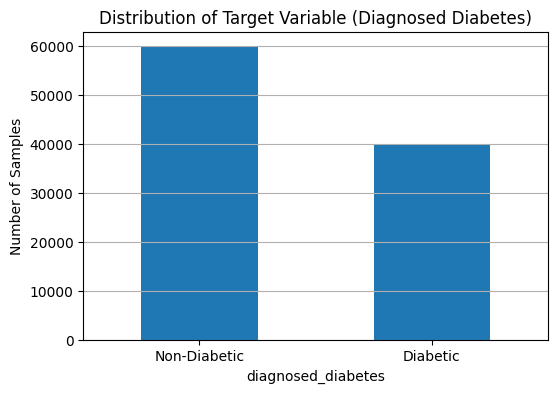

In [39]:
import matplotlib.pyplot as plt

target_counts = df["diagnosed_diabetes"].value_counts()

plt.figure(figsize=(6, 4))
target_counts.plot(kind="bar")
plt.xticks(ticks=[0, 1], labels=["Non-Diabetic", "Diabetic"], rotation=0)
plt.ylabel("Number of Samples")
plt.title("Distribution of Target Variable (Diagnosed Diabetes)")
plt.grid(axis="y")
plt.show()


FIGURE 2: Age Distribution of the Dataset

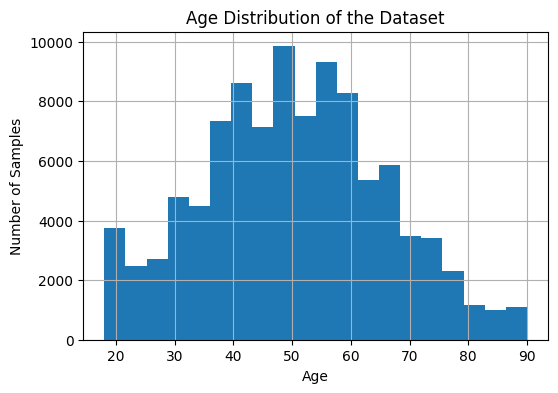

In [40]:
plt.figure(figsize=(6, 4))
plt.hist(df["age"], bins=20)
plt.xlabel("Age")
plt.ylabel("Number of Samples")
plt.title("Age Distribution of the Dataset")
plt.grid(True)
plt.show()


FIGURE 3: Correlation Heatmap of Numerical Features

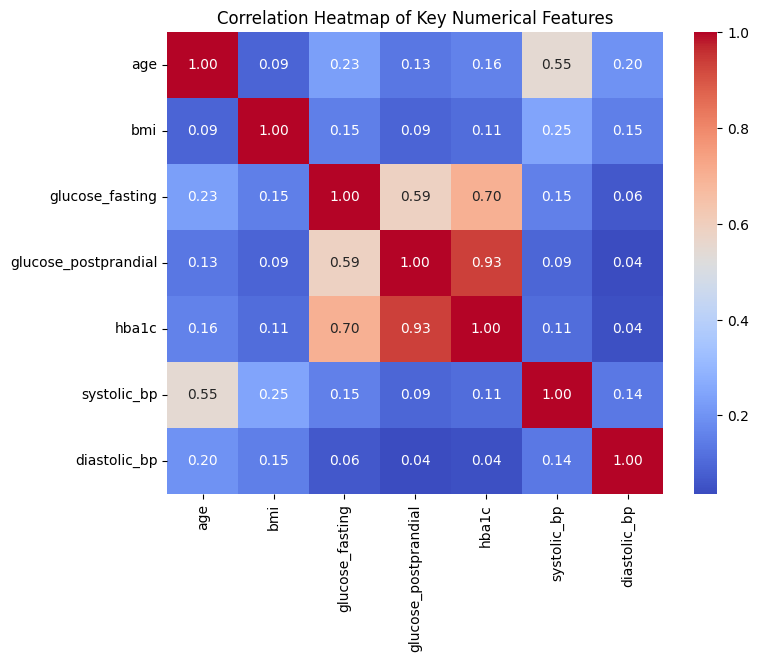

In [41]:
import seaborn as sns

numerical_features = [
    "age", "bmi", "glucose_fasting", "glucose_postprandial",
    "hba1c", "systolic_bp", "diastolic_bp"
]

corr_matrix = df[numerical_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Key Numerical Features")
plt.show()


FIGURE 4: Feature Importance / SHAP Summary Plot

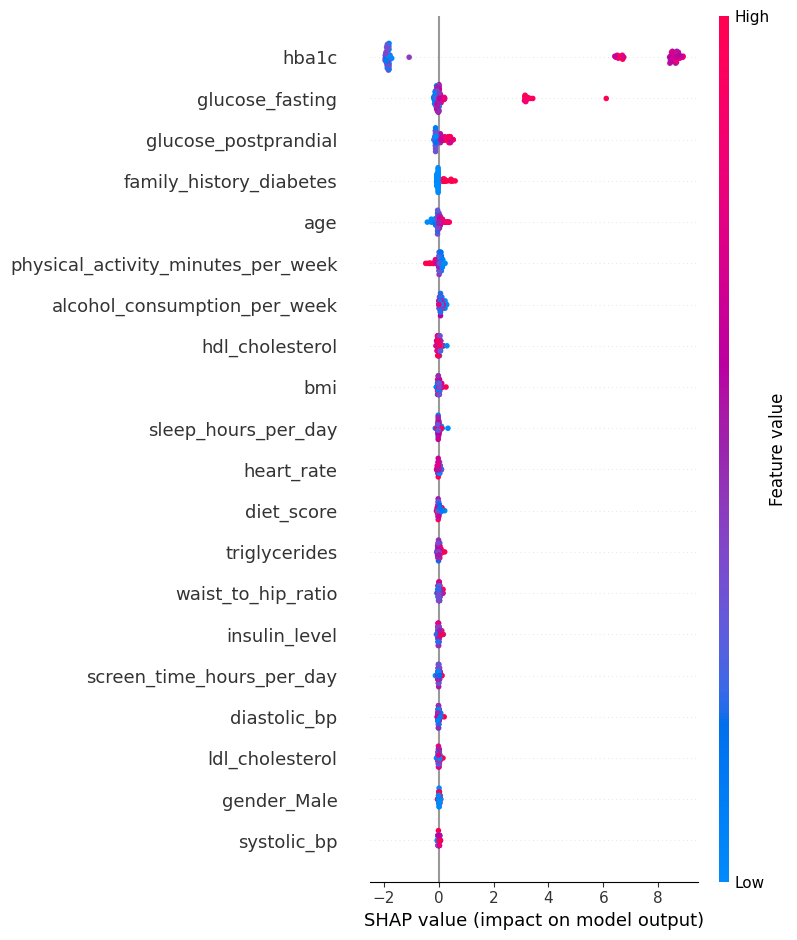

In [42]:
import shap

explainer = shap.Explainer(central_model)

# Use small sample for speed
shap_values = explainer(X_test_scaled[:100])

shap.summary_plot(
    shap_values,
    X_test_scaled[:100],
    feature_names=X_encoded.columns
)


FIGURE 5: Dataset Preprocessing Workflow

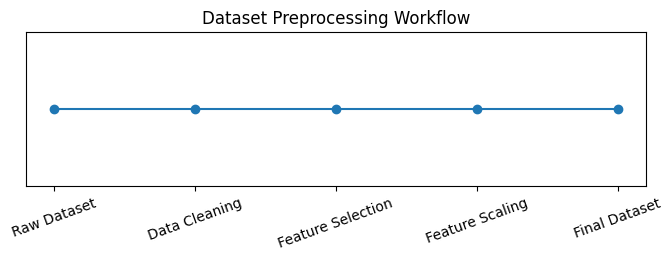

In [43]:
import matplotlib.pyplot as plt

steps = [
    "Raw Dataset",
    "Data Cleaning",
    "Feature Selection",
    "Feature Scaling",
    "Final Dataset"
]

plt.figure(figsize=(8, 2))
plt.plot(range(len(steps)), [1]*len(steps), "o-")
plt.yticks([])
plt.xticks(range(len(steps)), steps, rotation=20)
plt.title("Dataset Preprocessing Workflow")
plt.show()


MODEL 1: LOGISTIC REGRESSION (Baseline Model)

In [44]:
from sklearn.linear_model import LogisticRegression

# Train model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_bal, y_train_bal)

# Predict
y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, y_prob_log))
print(classification_report(y_test, y_pred_log))


Logistic Regression Accuracy: 0.8857
Logistic Regression ROC-AUC: 0.9338447916666667
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      8000
           1       0.93      0.88      0.90     12000

    accuracy                           0.89     20000
   macro avg       0.88      0.89      0.88     20000
weighted avg       0.89      0.89      0.89     20000



MODEL 2: RANDOM FOREST CLASSIFIER

In [45]:
from sklearn.ensemble import RandomForestClassifier

# Train model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train_bal, y_train_bal)

# Predict
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.91985
Random Forest ROC-AUC: 0.9419657083333334
              precision    recall  f1-score   support

           0       0.83      1.00      0.91      8000
           1       1.00      0.87      0.93     12000

    accuracy                           0.92     20000
   macro avg       0.92      0.93      0.92     20000
weighted avg       0.93      0.92      0.92     20000



MODEL COMPARISON TABLE – 6 MODELS

In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd


In [47]:
# Client 1
y_pred_c1 = local_models[0].predict(X_test_scaled)
y_prob_c1 = local_models[0].predict_proba(X_test_scaled)[:, 1]

# Client 2
y_pred_c2 = local_models[1].predict(X_test_scaled)
y_prob_c2 = local_models[1].predict_proba(X_test_scaled)[:, 1]


In [48]:
comparison_table_6 = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost (Centralized)",
        "XGBoost (Federated)",
        "XGBoost (Client-1)",
        "XGBoost (Client-2)"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, global_pred),
        accuracy_score(y_test, y_pred_c1),
        accuracy_score(y_test, y_pred_c2)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred),
        precision_score(y_test, global_pred),
        precision_score(y_test, y_pred_c1),
        precision_score(y_test, y_pred_c2)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred),
        recall_score(y_test, global_pred),
        recall_score(y_test, y_pred_c1),
        recall_score(y_test, y_pred_c2)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred),
        f1_score(y_test, global_pred),
        f1_score(y_test, y_pred_c1),
        f1_score(y_test, y_pred_c2)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, global_prob),
        roc_auc_score(y_test, y_prob_c1),
        roc_auc_score(y_test, y_prob_c2)
    ]
})

comparison_table_6


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.88570,0.926726,0.879000,0.902232,0.933845
1,Random Forest,0.91985,0.999904,0.866500,0.928434,0.941966
2,XGBoost (Centralized),0.91975,0.999615,0.866583,0.928358,0.943540
3,XGBoost (Federated),0.91990,1.000000,0.866500,0.928476,0.942864
4,XGBoost (Client-1),0.91975,0.999519,0.866667,0.928364,0.941849
5,XGBoost (Client-2),0.91970,0.999615,0.866500,0.928310,0.941098


HOW WE CHOOSE THE BEST MODEL

STEP 1: Create a Results Dictionary

In [49]:
results = {
    "Logistic Regression": {
        "Accuracy": accuracy_score(y_test, y_pred_log),
        "Recall": recall_score(y_test, y_pred_log),
        "F1": f1_score(y_test, y_pred_log),
        "ROC_AUC": roc_auc_score(y_test, y_prob_log)
    },
    "Random Forest": {
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Recall": recall_score(y_test, y_pred_rf),
        "F1": f1_score(y_test, y_pred_rf),
        "ROC_AUC": roc_auc_score(y_test, y_prob_rf)
    },
    "XGBoost (Centralized)": {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    },
    "XGBoost (Federated)": {
        "Accuracy": accuracy_score(y_test, global_pred),
        "Recall": recall_score(y_test, global_pred),
        "F1": f1_score(y_test, global_pred),
        "ROC_AUC": roc_auc_score(y_test, global_prob)
    },
    "XGBoost (Client-1)": {
        "Accuracy": accuracy_score(y_test, y_pred_c1),
        "Recall": recall_score(y_test, y_pred_c1),
        "F1": f1_score(y_test, y_pred_c1),
        "ROC_AUC": roc_auc_score(y_test, y_prob_c1)
    },
    "XGBoost (Client-2)": {
        "Accuracy": accuracy_score(y_test, y_pred_c2),
        "Recall": recall_score(y_test, y_pred_c2),
        "F1": f1_score(y_test, y_pred_c2),
        "ROC_AUC": roc_auc_score(y_test, y_prob_c2)
    }
}


STEP 2: Convert to DataFrame

In [50]:
results_df = pd.DataFrame(results).T
results_df


,Accuracy,Recall,F1,ROC_AUC
Logistic Regression,0.88570,0.879000,0.902232,0.933845
Random Forest,0.91985,0.866500,0.928434,0.941966
XGBoost (Centralized),0.91975,0.866583,0.928358,0.943540
XGBoost (Federated),0.91990,0.866500,0.928476,0.942864
XGBoost (Client-1),0.91975,0.866667,0.928364,0.941849
XGBoost (Client-2),0.91970,0.866500,0.928310,0.941098


STEP 3: Normalize Scores (Fair Comparison)

In [51]:
normalized_df = (results_df - results_df.min()) / (results_df.max() - results_df.min())
normalized_df


,Accuracy,Recall,F1,ROC_AUC
Logistic Regression,0.000000,1.000000,0.000000,0.000000
Random Forest,0.998538,0.000000,0.998420,0.837596
XGBoost (Centralized),0.995614,0.006667,0.995506,1.000000
XGBoost (Federated),1.000000,0.000000,1.000000,0.930272
XGBoost (Client-1),0.995614,0.013333,0.995749,0.825605
XGBoost (Client-2),0.994152,0.000000,0.993683,0.748134


STEP 4: Compute Final Score (Weighted)

In [52]:
weights = {
    "Accuracy": 0.3,
    "Recall": 0.3,
    "F1": 0.2,
    "ROC_AUC": 0.2
}

normalized_df["Final_Score"] = (
    normalized_df["Accuracy"] * weights["Accuracy"] +
    normalized_df["Recall"] * weights["Recall"] +
    normalized_df["F1"] * weights["F1"] +
    normalized_df["ROC_AUC"] * weights["ROC_AUC"]
)

normalized_df.sort_values("Final_Score", ascending=False)


,Accuracy,Recall,F1,ROC_AUC,Final_Score
XGBoost (Centralized),0.995614,0.006667,0.995506,1.000000,0.699785
XGBoost (Federated),1.000000,0.000000,1.000000,0.930272,0.686054
XGBoost (Client-1),0.995614,0.013333,0.995749,0.825605,0.666955
Random Forest,0.998538,0.000000,0.998420,0.837596,0.666765
XGBoost (Client-2),0.994152,0.000000,0.993683,0.748134,0.646609
Logistic Regression,0.000000,1.000000,0.000000,0.000000,0.300000


STEP 5: Select the Best Model

In [53]:
best_model_name = normalized_df["Final_Score"].idxmax()
best_model_score = normalized_df.loc[best_model_name, "Final_Score"]

print("Best Model Selected:", best_model_name)
print("Final Weighted Score:", best_model_score)


Best Model Selected: XGBoost (Centralized)
Final Weighted Score: 0.6997853321399146


CHECK FINAL ACCURACY OF BEST MODEL

In [54]:
model_predictions = {
    "Logistic Regression": y_pred_log,
    "Random Forest": y_pred_rf,
    "XGBoost (Centralized)": y_pred,
    "XGBoost (Federated)": global_pred,
    "XGBoost (Client-1)": y_pred_c1,
    "XGBoost (Client-2)": y_pred_c2
}


In [55]:
final_predictions = model_predictions[best_model_name]


In [56]:
final_accuracy = accuracy_score(y_test, final_predictions)

print("Best Model:", best_model_name)
print("Final Accuracy of Best Model:", final_accuracy)


Best Model: XGBoost (Centralized)
Final Accuracy of Best Model: 0.91975


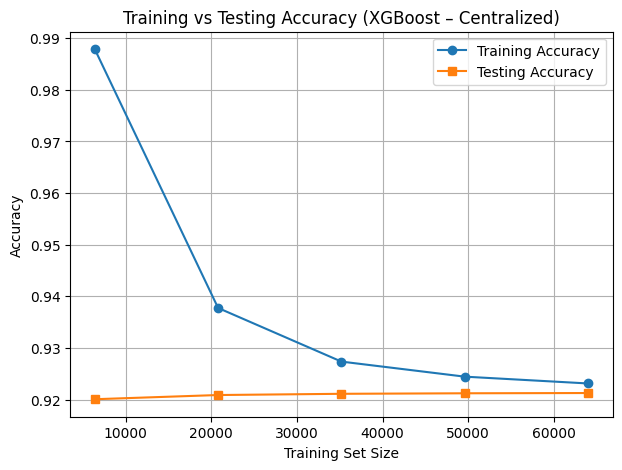

In [65]:
# TRAINING vs TESTING GRAPH (BEST MODEL: XGBoost – Centralized)

from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# STEP 1: Generate learning curve data
train_sizes, train_scores, test_scores = learning_curve(
    estimator=central_model,      # Best model: XGBoost (Centralized)
    X=X_train_scaled,
    y=y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

# STEP 2: Compute mean accuracy
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

# STEP 3: Plot Training vs Testing Accuracy
plt.figure(figsize=(7, 5))
plt.plot(train_sizes, train_mean, marker="o", label="Training Accuracy")
plt.plot(train_sizes, test_mean, marker="s", label="Testing Accuracy")

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Training vs Testing Accuracy (XGBoost – Centralized)")
plt.legend()
plt.grid(True)
plt.show()


ABLATION STUDY DESIGN

STEP 1: Helper Function to Train & Evaluate Model

In [57]:
from sklearn.metrics import accuracy_score, roc_auc_score

def train_evaluate(X_train, y_train, X_test, y_test):
    model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    return accuracy_score(y_test, y_pred), roc_auc_score(y_test, y_prob)


STEP 2: Baseline (Full Pipeline)

In [58]:
baseline_acc, baseline_auc = train_evaluate(
    X_train_bal, y_train_bal,
    X_test_scaled, y_test
)


STEP 3: Ablation-1 (Without SMOTE)

In [59]:
acc_no_smote, auc_no_smote = train_evaluate(
    X_train_scaled, y_train,
    X_test_scaled, y_test
)


STEP 4: Ablation-2 (Without Scaling)

In [60]:
acc_no_scaling, auc_no_scaling = train_evaluate(
    X_train, y_train,
    X_test, y_test
)


STEP 5: Ablation-3 (Without Categorical Encoding)

In [61]:
X_numeric = X.select_dtypes(exclude=["object"])

X_tr, X_te, y_tr, y_te = train_test_split(
    X_numeric, y, test_size=0.2, random_state=42, stratify=y
)

acc_no_encoding, auc_no_encoding = train_evaluate(
    X_tr, y_tr, X_te, y_te
)


STEP 6: Ablation-4 (Without Federated Learning)

In [62]:
# Centralized only (already trained)
acc_no_federated = accuracy_score(y_test, y_pred)
auc_no_federated = roc_auc_score(y_test, y_prob)


STEP 7: Ablation Study Results Table

In [63]:
ablation_table = pd.DataFrame({
    "Experiment": [
        "Baseline (Full Pipeline)",
        "Without SMOTE",
        "Without Scaling",
        "Without Encoding",
        "Without Federated Learning"
    ],
    "Accuracy": [
        baseline_acc,
        acc_no_smote,
        acc_no_scaling,
        acc_no_encoding,
        acc_no_federated
    ],
    "ROC-AUC": [
        baseline_auc,
        auc_no_smote,
        auc_no_scaling,
        auc_no_encoding,
        auc_no_federated
    ]
})

ablation_table


,Experiment,Accuracy,ROC-AUC
0,Baseline (Full Pipeline),0.91975,0.943540
1,Without SMOTE,0.91990,0.943342
2,Without Scaling,0.91990,0.943342
3,Without Encoding,0.91995,0.943049
4,Without Federated Learning,0.91975,0.943540


NUMBER OF TRAINABLE PARAMETERS

In [64]:
import pandas as pd

# -------------------------------
# Logistic Regression
# -------------------------------
lr_params = log_model.coef_.size + log_model.intercept_.size

# -------------------------------
# Random Forest (total nodes across all trees)
# -------------------------------
rf_params = sum(
    tree.tree_.node_count for tree in rf_model.estimators_
)

# -------------------------------
# XGBoost Centralized (count leaf nodes)
# -------------------------------
xgb_booster = central_model.get_booster()
xgb_trees = xgb_booster.get_dump()
xgb_params = sum(tree.count("leaf") for tree in xgb_trees)

# -------------------------------
# XGBoost Federated (use client-1 as representative)
# -------------------------------
fed_booster = local_models[0].get_booster()
fed_trees = fed_booster.get_dump()
fed_params = sum(tree.count("leaf") for tree in fed_trees)

# -------------------------------
# XGBoost Client-1
# -------------------------------
c1_booster = local_models[0].get_booster()
c1_params = sum(tree.count("leaf") for tree in c1_booster.get_dump())

# -------------------------------
# XGBoost Client-2
# -------------------------------
c2_booster = local_models[1].get_booster()
c2_params = sum(tree.count("leaf") for tree in c2_booster.get_dump())

# -------------------------------
# Create parameter comparison table
# -------------------------------
parameter_table = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost (Centralized)",
        "XGBoost (Federated)",
        "XGBoost (Client-1)",
        "XGBoost (Client-2)"
    ],
    "Number of Trainable Parameters": [
        lr_params,
        rf_params,
        xgb_params,
        fed_params,
        c1_params,
        c2_params
    ]
})

print(parameter_table)


                   Model  Number of Trainable Parameters
0    Logistic Regression                              41
1          Random Forest                          129810
2  XGBoost (Centralized)                            9411
3    XGBoost (Federated)                            5374
4     XGBoost (Client-1)                            5374
5     XGBoost (Client-2)                            5377
